In [1]:
print("hello")

hello


In [2]:
import pandas as pd
print("pandas imported")

pandas imported


In [3]:
df = pd.read_csv('../data/DataCoSupplyChainDataset.csv', encoding='latin-1')
df.shape

(180519, 53)

In [4]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])
df[['order date (DateOrders)', 'shipping date (DateOrders)']].dtypes

order date (DateOrders)       datetime64[us]
shipping date (DateOrders)    datetime64[us]
dtype: object

In [5]:
df['actual_delay_days'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['is_late'] = (df['actual_delay_days'] > df['Days for shipment (scheduled)']).astype(int)
df['order_month'] = df['order date (DateOrders)'].dt.month

df[['actual_delay_days', 'is_late', 'order_month']].describe()

,actual_delay_days,is_late,order_month
count,180519.000000,180519.000000,180519.000000
mean,3.471856,0.546995,6.235449
std,1.670471,0.497788,3.403571
min,0.000000,0.000000,1.000000
25%,2.000000,0.000000,3.000000
50%,3.000000,1.000000,6.000000
75%,5.000000,1.000000,9.000000
max,6.000000,1.000000,12.000000


In [6]:
leak_free_features = [
    'Shipping Mode',
    'Order Region',
    'Order Country', 
    'Order State',
    'Category Name',
    'Days for shipment (scheduled)',
    'order_month',
    'Order Item Quantity',
    'Order Item Discount Rate'
]

df[leak_free_features].info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Shipping Mode                  180519 non-null  str    
 1   Order Region                   180519 non-null  str    
 2   Order Country                  180519 non-null  str    
 3   Order State                    180519 non-null  str    
 4   Category Name                  180519 non-null  str    
 5   Days for shipment (scheduled)  180519 non-null  int64  
 6   order_month                    180519 non-null  int32  
 7   Order Item Quantity            180519 non-null  int64  
 8   Order Item Discount Rate       180519 non-null  float64
dtypes: float64(1), int32(1), int64(2), str(5)
memory usage: 11.7 MB


In [7]:
leak_free_features = [
    'Shipping Mode',
    'Order Region',
    'Order Country', 
    'Order State',
    'Category Name',
    'Days for shipment (scheduled)',
    'order_month',
    'Order Item Quantity',
    'Order Item Discount Rate'
]

df[leak_free_features].info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Shipping Mode                  180519 non-null  str    
 1   Order Region                   180519 non-null  str    
 2   Order Country                  180519 non-null  str    
 3   Order State                    180519 non-null  str    
 4   Category Name                  180519 non-null  str    
 5   Days for shipment (scheduled)  180519 non-null  int64  
 6   order_month                    180519 non-null  int32  
 7   Order Item Quantity            180519 non-null  int64  
 8   Order Item Discount Rate       180519 non-null  float64
dtypes: float64(1), int32(1), int64(2), str(5)
memory usage: 11.7 MB


In [8]:
categorical_cols = ['Shipping Mode', 'Order Region', 'Order Country', 'Order State', 'Category Name']

df_encoded = pd.get_dummies(df[leak_free_features + ['is_late']], columns=categorical_cols, drop_first=True)
df_encoded.shape

(180519, 1330)

In [9]:
for col in categorical_cols:
    print(col, df[col].nunique())

Shipping Mode 4
Order Region 23
Order Country 164
Order State 1089
Category Name 50


In [10]:
categorical_cols = ['Shipping Mode', 'Order Region', 'Order Country', 'Category Name']

df_encoded = pd.get_dummies(df[leak_free_features + ['is_late']].drop(columns=['Order State']), columns=categorical_cols, drop_first=True)
df_encoded.shape

(180519, 242)

In [11]:
df_encoded['order_date'] = df['order date (DateOrders)']
df_encoded = df_encoded.sort_values('order_date')

split_point = int(len(df_encoded) * 0.8)
train = df_encoded.iloc[:split_point]
test = df_encoded.iloc[split_point:]

print("Train date range:", train['order_date'].min(), "to", train['order_date'].max())
print("Test date range:", test['order_date'].min(), "to", test['order_date'].max())
print("Train size:", len(train), "Test size:", len(test))

Train date range: 2015-01-01 00:00:00 to 2017-04-22 15:17:00
Test date range: 2017-04-22 15:17:00 to 2018-01-31 23:38:00
Train size: 144415 Test size: 36104


In [12]:
feature_cols = [col for col in df_encoded.columns if col not in ['is_late', 'order_date']]

X_train = train[feature_cols]
y_train = train['is_late']
X_test = test[feature_cols]
y_test = test['is_late']

X_train.shape, X_test.shape

((144415, 241), (36104, 241))

In [14]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, solver='liblinear')
log_model.fit(X_train, y_train)

print("Model trained")

Model trained


In [15]:
from sklearn.metrics import average_precision_score, classification_report

y_pred_proba = log_model.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, y_pred_proba)

print("PR-AUC:", pr_auc)
print()
print(classification_report(y_test, log_model.predict(X_test)))

PR-AUC: 0.8416247987767925

              precision    recall  f1-score   support

           0       0.64      0.90      0.75     16396
           1       0.87      0.57      0.69     19708

    accuracy                           0.72     36104
   macro avg       0.75      0.74      0.72     36104
weighted avg       0.77      0.72      0.72     36104



In [16]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

print("XGBoost trained")

XGBoost trained


In [17]:
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
pr_auc_xgb = average_precision_score(y_test, y_pred_proba_xgb)

print("XGBoost PR-AUC:", pr_auc_xgb)
print()
print(classification_report(y_test, xgb_model.predict(X_test)))

XGBoost PR-AUC: 0.843011985359833

              precision    recall  f1-score   support

           0       0.64      0.90      0.75     16396
           1       0.87      0.58      0.69     19708

    accuracy                           0.72     36104
   macro avg       0.75      0.74      0.72     36104
weighted avg       0.76      0.72      0.72     36104



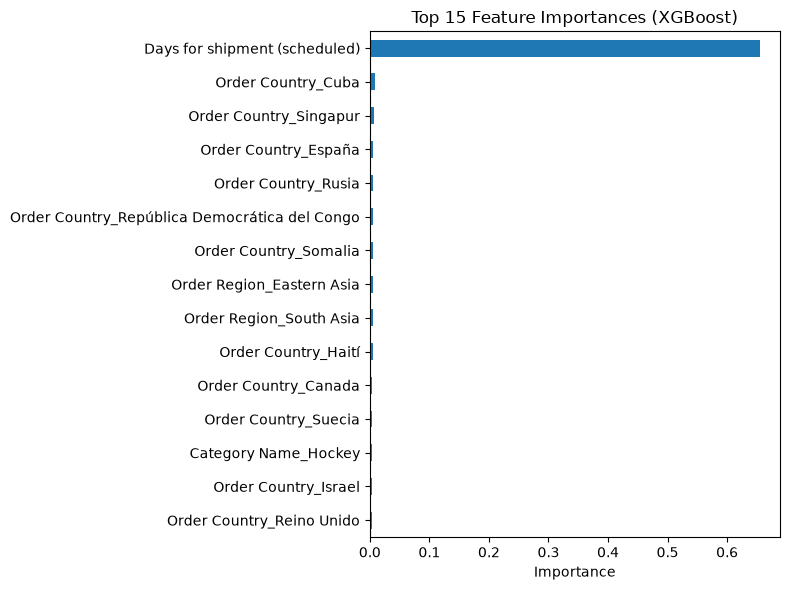

In [18]:
import matplotlib.pyplot as plt

importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15).plot(kind='barh', figsize=(8,6))
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()